# Multi-Label Text Classification with BERT and PyTorch Lightning

## Dataset


The dataset was artificially generated by Claude, producing 100 question examples with all labels well balanced.

Each comment may belong to **one** of four categories:

| Label                      | Meaning                          |
|----------------------------|----------------------------------|
| calidad                    | Quality or performance issues    |
| velocidad                  | Speed or responsiveness          |
| rendimiento                | Performance or efficiency        |
| OEE                        | Overall Equipment Effectiveness  |

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
import numpy as np

from tqdm.auto import tqdm
import glob
import torch
import torch.nn as nn
from torch.utils.data import random_split, Dataset, DataLoader
from torch.optim import AdamW

from transformers import BertTokenizerFast as BertTokenizer, BertModel, get_linear_schedule_with_warmup

import pytorch_lightning as pl
import torchmetrics
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import TQDMProgressBar, RichProgressBar

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix

import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from torchmetrics import AUROC, Accuracy, F1Score, Precision, Recall, AveragePrecision, HammingDistance


import sys
from pathlib import Path

SRC_PATH = Path.cwd().resolve().parents[1] / "src"
sys.path.insert(0, str(SRC_PATH))

from settings import DATA_DIR, LOGS_DIR

/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parametros para gráficos

%matplotlib inline
%config InlineBackend.figure_format='retina'

RANDOM_SEED = 42

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = 8,6

pl.seed_everything(RANDOM_SEED)

Seed set to 42


42

## Dataset


The dataset was artificially generated by Claude, producing 100 question examples with all labels well balanced.

Each comment may belong to **one** of four categories:

| Label                      | Meaning                          |
|----------------------------|----------------------------------|
| calidad                    | Quality or performance issues    |
| velocidad                  | Speed or responsiveness          |
| rendimiento                | Performance or efficiency       |
| OEE                        | Overall Equipment Effectiveness  |

In [3]:
import pandas as pd

csv_path = f"{DATA_DIR}/OEE_dataset_clasificado_balanced_single_label.csv"
df = pd.read_csv(csv_path, encoding="utf-8")

LABEL_COLUMNS = ["calidad", "velocidad", "rendimiento", "eficiencia_OEE"]
df[LABEL_COLUMNS] = (
    df[LABEL_COLUMNS]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

print(f"Dataset cargado: {csv_path}")
print(f"Shape: {df.shape}")
print("\nConteo por etiqueta:")
print(df[LABEL_COLUMNS].sum())
print("\nEtiquetas activas por fila (debe ser 1):")
print(df[LABEL_COLUMNS].sum(axis=1).value_counts().sort_index())
df.head()


Dataset cargado: /home/emanosalvasb/PUBLICO/DEEP LEARNING/usfq-mmia-main/data/OEE_dataset_clasificado_balanced_single_label.csv
Shape: (524, 5)

Conteo por etiqueta:
calidad           131
velocidad         131
rendimiento       131
eficiencia_OEE    131
dtype: int64

Etiquetas activas por fila (debe ser 1):
1    524
Name: count, dtype: int64


,pregunta,calidad,velocidad,rendimiento,eficiencia_OEE
0,¿Cómo monitorear OEE remotamente en plantas di...,0,0,0,1
1,¿Cómo balanced scorecard integra Rendimiento d...,0,0,1,0
2,¿Cómo puede la visión artificial contar piezas...,0,1,0,0
3,¿Cómo política de amortización afecta decision...,0,0,0,1
4,¿Qué indicadores alertan sobre caída próxima d...,0,0,0,1


El dataset original tenía superposición fuerte de etiquetas (casi todas las filas con múltiples etiquetas activas), lo que inducía sesgo en la inferencia.

Para corregirlo, se usa un dataset **balanceado y de etiqueta única** (`single-label`), con el mismo número de ejemplos por clase.

Así, el modelo aprende una frontera más clara entre `calidad`, `velocidad`, `rendimiento` y `eficiencia_OEE`, reduciendo predicciones espurias de `velocidad`.


## Preparación y análisis inicial del dataset

Esta celda crea una copia del dataframe, define las columnas de etiquetas, las convierte a valores numéricos, y muestra el tamaño del dataset junto con el conteo de preguntas por etiqueta, confirmando el uso del dataset completo sin rebalanceo.

In [4]:
filter_df = df.copy()
LABEL_COLUMNS = ["calidad", "velocidad", "rendimiento", "eficiencia_OEE"]

filter_df[LABEL_COLUMNS] = (
    filter_df[LABEL_COLUMNS]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

print("Usando dataset balanceado y single-label.")
print("Tamaño del dataset:", filter_df.shape)
print("\nCantidad de preguntas por etiqueta:")
for etiqueta, cantidad in filter_df[LABEL_COLUMNS].sum().items():
    print(f"{etiqueta}: {cantidad}")


Usando dataset balanceado y single-label.
Tamaño del dataset: (524, 5)

Cantidad de preguntas por etiqueta:
calidad: 131
velocidad: 131
rendimiento: 131
eficiencia_OEE: 131


## División del Dataset en Conjuntos de Entrenamiento, Validación y Prueba

Esta celda divide el dataset filtrado (`filter_df`) en tres subconjuntos: entrenamiento (80%), validación (10%) y prueba (10%). Se realiza un shuffle aleatorio del dataframe para asegurar una distribución equilibrada de las etiquetas en cada subconjunto, utilizando una semilla fija para reproducibilidad. Finalmente, se imprime el tamaño de cada subconjunto para confirmar la división.

In [5]:
train_frac, val_frac, test_frac = 0.8, 0.1, 0.1

# Shuffle the DataFrame
filter_df = filter_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Calcular los indices para separar los subsets
train_end = int(train_frac * len(filter_df))
val_end = train_end + int(val_frac * len(filter_df))

# Split the DataFrame
train_df = filter_df[:train_end]
val_df = filter_df[train_end:val_end]
test_df = filter_df[val_end:]

print("Train DataFrame:\n", len(train_df))
print("Validation DataFrame:\n", len(val_df))
print("Test DataFrame:\n", len(test_df))

Train DataFrame:
 419
Validation DataFrame:
 52
Test DataFrame:
 53


In [6]:
train_df.head()

,pregunta,calidad,velocidad,rendimiento,eficiencia_OEE
0,¿Cómo Monte Carlo estima variabilidad esperada...,0,0,0,1
1,¿Qué diferencia entre velocidad teórica origin...,0,1,0,0
2,¿Cómo cambio de proveedor de materia prima afe...,1,0,0,0
3,¿Qué relación tiene estandarización de proceso...,0,0,0,1
4,¿Cómo programa de 5S impacta simultáneamente C...,1,0,0,0


In [7]:
print(filter_df[LABEL_COLUMNS].dtypes)
print(filter_df[LABEL_COLUMNS].head())

calidad           int64
velocidad         int64
rendimiento       int64
eficiencia_OEE    int64
dtype: object
   calidad  velocidad  rendimiento  eficiencia_OEE
0        0          0            0               1
1        0          1            0               0
2        1          0            0               0
3        0          0            0               1
4        1          0            0               0


In [8]:
no_label_mask = (filter_df[LABEL_COLUMNS].sum(axis=1) == 0)
multi_label_mask = (filter_df[LABEL_COLUMNS].sum(axis=1) > 1)
print("Rows with no label:", no_label_mask.sum())
print("Rows with multiple labels:", multi_label_mask.sum())

Rows with no label: 0
Rows with multiple labels: 0


## Visualización de la Distribución de Etiquetas

Esta celda genera un gráfico de barras para visualizar la distribución de las etiquetas en el conjunto de datos completo. Utiliza seaborn para crear el gráfico y matplotlib para personalizaciones adicionales, como una escala logarítmica en el eje y para resaltar mejor los conteos de muestras por etiqueta. Se incluye el conteo exacto en cada barra y ajustes de estilo para una mejor legibilidad.

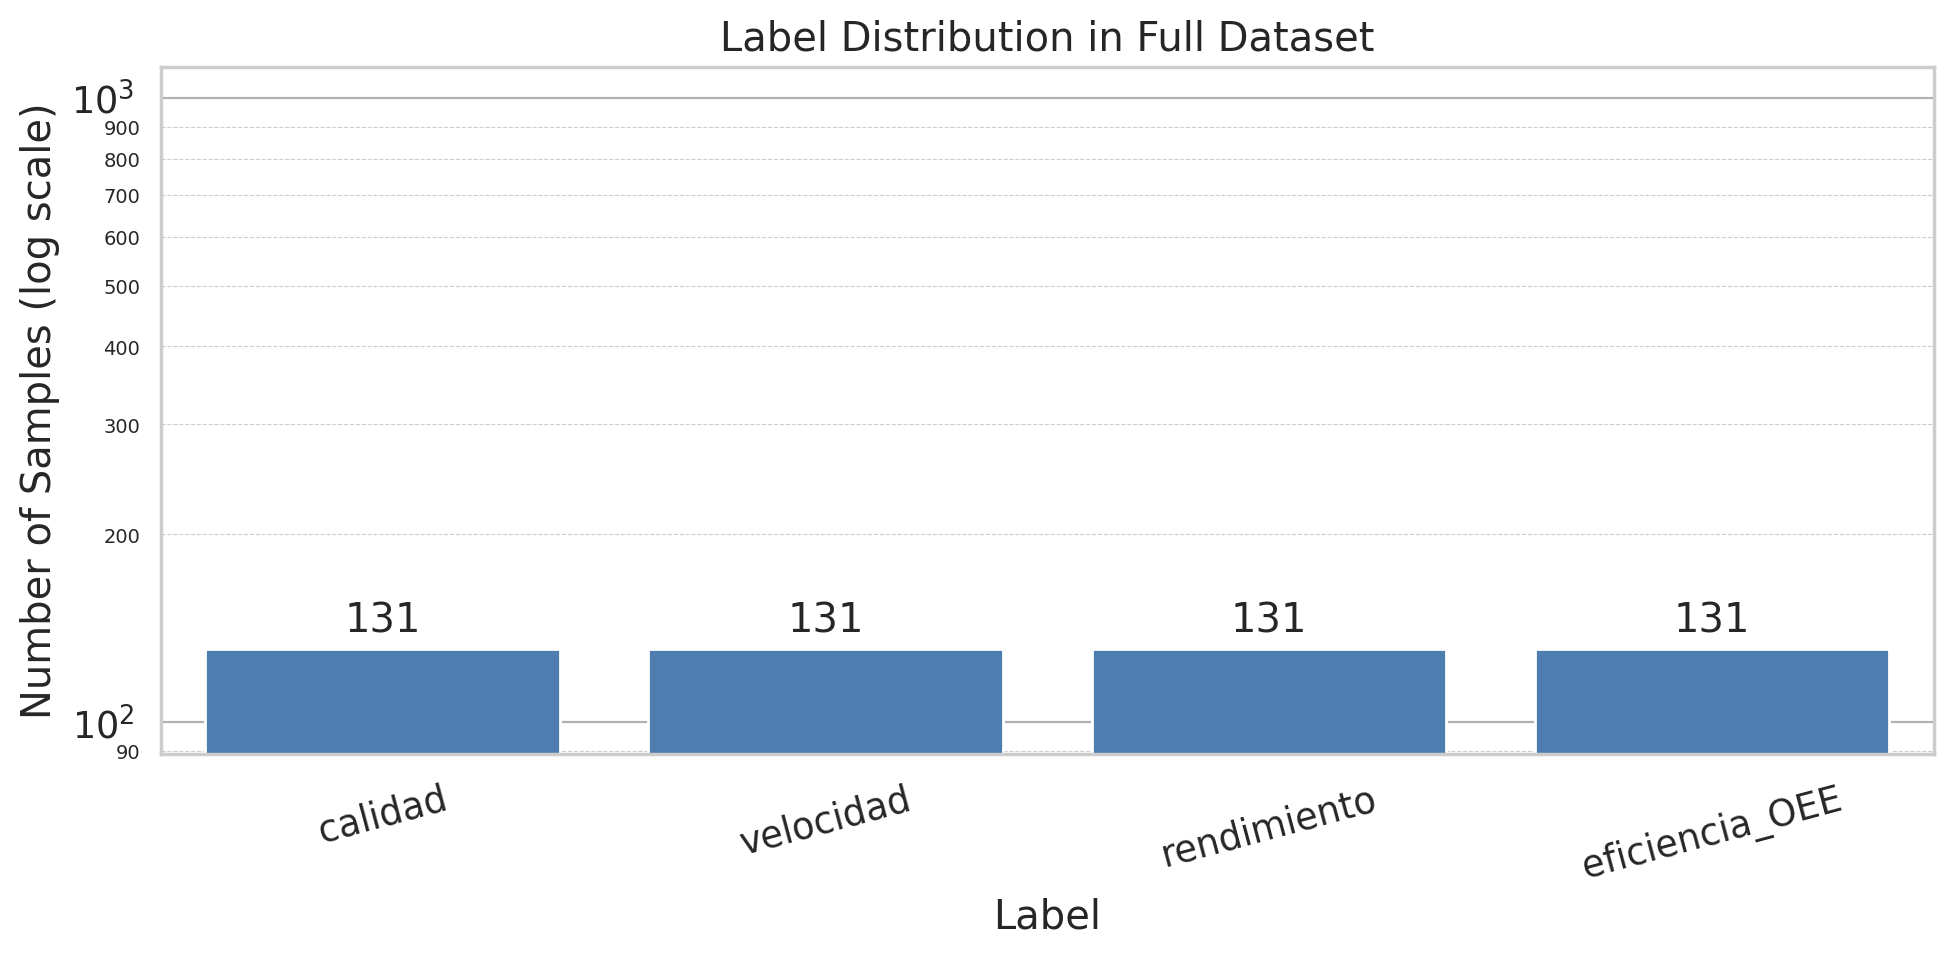

In [9]:
from matplotlib.ticker import ScalarFormatter

# label_counts = filter_df[LABEL_COLUMNS].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sort_values(ascending=False)
label_counts = filter_df[LABEL_COLUMNS].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    color="#3d7ebf"
)

ax.bar_label(ax.containers[0], fmt="%d", padding=3)
ax.set_yscale("log")
ax.yaxis.grid(
    True, which="major", linestyle="-", linewidth=0.8, alpha=0.6, color="gray"
)
ax.yaxis.grid(
    True, which="minor", linestyle="--", linewidth=0.4, alpha=0.4, color="gray"
)
ax.set_axisbelow(True)
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.tick_params(axis="y", which="minor", labelsize=7)

plt.title("Label Distribution in Full Dataset")
plt.xlabel("Label")
plt.ylabel("Number of Samples (log scale)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Inicializar el tokenizador de BERT

Esta celda configura el tokenizador BERT utilizando el modelo preentrenado 'bert-base-cased' de Hugging Face Transformers. El tokenizador es esencial para convertir textos de entrada en tokens que el modelo BERT pueda procesar durante el entrenamiento e inferencia.

In [10]:
BERT_MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
tokenizer

BertTokenizer(name_or_path='dccuchile/bert-base-spanish-wwm-cased', vocab_size=31002, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

## Inspección de una Muestra de Datos

Esta celda selecciona una fila de ejemplo del conjunto de entrenamiento (`train_df`), extrae la pregunta y las etiquetas correspondientes, y las imprime para verificar la estructura y contenido de los datos antes de proceder con el tokenizado o entrenamiento del modelo.

In [11]:
sample_row = train_df.iloc[5]
pregunta = sample_row.pregunta
print(pregunta)

sample_labels = sample_row[LABEL_COLUMNS]

print()
print(sample_labels.to_dict())

¿Qué diferencia existe entre un defecto y un rechazo en el OEE, y cómo afecta cada uno a la velocidad efectiva de la línea de producción?

{'calidad': 1, 'velocidad': 0, 'rendimiento': 0, 'eficiencia_OEE': 0}


## Tokenización de una Muestra de Datos

Esta celda tokeniza una pregunta de ejemplo del conjunto de entrenamiento (`train_df`) utilizando el tokenizador BERT previamente inicializado. Se configura para agregar tokens especiales, limitar la longitud máxima a 512 tokens, no devolver `token_type_ids`, no aplicar padding, devolver la máscara de atención, y retornar los tensores en formato PyTorch. Finalmente, se imprimen las claves del objeto `BatchEncoding` resultante para verificar la estructura de la tokenización.

In [12]:
encoding_sample = tokenizer(
  pregunta,
  add_special_tokens=True,
  max_length=512,
  return_token_type_ids=False,
  padding="do_not_pad",
  return_attention_mask=True,
  return_tensors='pt',
)

## Creación del Dataset Personalizado para Preguntas OEE

Esta celda define una clase personalizada `PreguntasOEEDataset` que hereda de `Dataset` de PyTorch. Esta clase se utiliza para preparar los datos de preguntas y etiquetas para el entrenamiento del modelo BERT. El dataset tokeniza cada pregunta utilizando el tokenizador BERT, aplica padding y truncamiento a una longitud máxima de 512 tokens, y devuelve un diccionario con los inputs necesarios para el modelo, incluyendo `input_ids`, `attention_mask` y las etiquetas como tensores flotantes.

In [13]:
class PreguntasOEEDataset(Dataset):

  def __init__(
    self,
    data: pd.DataFrame,
    tokenizer: BertTokenizer,
    max_token_len: int = 512
  ):
    self.tokenizer = tokenizer
    self.data = data
    self.max_token_len = max_token_len

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index: int):
    data_row = self.data.iloc[index]

    pregunta = data_row.pregunta
    labels = data_row[LABEL_COLUMNS].astype(int).values
    label_idx = int(np.argmax(labels))

    encoding = self.tokenizer(
      pregunta,
      add_special_tokens=True,
      max_length=self.max_token_len,
      return_token_type_ids=False,
      padding="max_length",
      truncation=True,
      return_attention_mask=True,
      return_tensors="pt",
    )

    return dict(
      pregunta=pregunta,
      input_ids=encoding["input_ids"].flatten(),
      attention_mask=encoding["attention_mask"].flatten(),
      labels=torch.tensor(label_idx, dtype=torch.long)
    )


Preparar el dataset de entrenamiento usando el tokenizador ya inicializado y cargar el modelo BERT base que se utilizará como encoder en el modelo de clasificación.

In [14]:
MAX_TOKEN_COUNT = 512
train_dataset = PreguntasOEEDataset(train_df, tokenizer, max_token_len=MAX_TOKEN_COUNT)
bert_model = BertModel.from_pretrained(BERT_MODEL_NAME, return_dict=True)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 12151.15it/s]
BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly 

## Creación del DataModule para Preguntas OEE

Esta celda define la clase `PreguntasOEEDataModule`, que hereda de `pl.LightningDataModule` de PyTorch Lightning. Esta clase se encarga de preparar y gestionar los dataloaders para los conjuntos de entrenamiento, validación, prueba y predicción, utilizando el dataset personalizado `PreguntasOEEDataset` y el tokenizador BERT. Permite configurar el tamaño de batch y la longitud máxima de tokens, facilitando el manejo eficiente de los datos durante el entrenamiento y evaluación del modelo.

In [15]:
class PreguntasOEEDataModule(pl.LightningDataModule):

  def __init__(self, train_df, val_df, test_df, tokenizer, batch_size=8, max_token_len=512):
    super().__init__()
    self.batch_size = batch_size
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df
    self.tokenizer = tokenizer
    self.max_token_len = max_token_len
    self.predict_texts = []

  def setup(self, stage=None):
    self.train_dataset = PreguntasOEEDataset(
      self.train_df,
      self.tokenizer,
      self.max_token_len
    )

    self.val_dataset = PreguntasOEEDataset(
      self.val_df,
      self.tokenizer,
      self.max_token_len
    )

    self.test_dataset = PreguntasOEEDataset(
      self.test_df,
      self.tokenizer,
      self.max_token_len
    )

  def train_dataloader(self):
    return DataLoader(
      self.train_dataset,
      batch_size=self.batch_size,
      shuffle=True,
      num_workers=0
    )

  def val_dataloader(self):
    return DataLoader(
      self.val_dataset,
      batch_size=self.batch_size,
      num_workers=0
    )

  def test_dataloader(self):
    return DataLoader(
      self.test_dataset,
      batch_size=self.batch_size,
      num_workers=0
    )

  def predict_dataloader(self):
    df = pd.DataFrame({
      'pregunta': self.predict_texts,
      **{col: [0] * len(self.predict_texts) for col in LABEL_COLUMNS}
    })
    dataset = PreguntasOEEDataset(df, self.tokenizer, self.max_token_len)
    return DataLoader(dataset, batch_size=self.batch_size, num_workers=0)

## Instanciar el DataModule

En esta celda se fija el tamaño de batch y se crea la instancia de `PreguntasOEEDataModule`
usando los dataframes de entrenamiento, validación y prueba, junto con el tokenizador y
la longitud máxima de tokens.

In [16]:
BATCH_SIZE = 32

data_module = PreguntasOEEDataModule(
  train_df,
  val_df,
  test_df,
  tokenizer,
  batch_size=BATCH_SIZE,
  max_token_len=MAX_TOKEN_COUNT
)

## Definición del modelo de clasificación multi-etiqueta (BERT + Lightning)

En esta celda se implementa la clase `PreguntasOEETagger`, un `LightningModule` que emplea BERT como encoder y una capa lineal de salida para predecir las cinco etiquetas de la tarea. Se define la función de pérdida adecuada para multi-etiquetas (`BCEWithLogitsLoss`), métricas de evaluación (accuracy, AUROC, F1, etc.) y el optimizador con scheduler para el entrenamiento.

In [17]:
class PreguntasOEETagger(pl.LightningModule):

    def __init__(
        self,
        n_classes: int,
        n_training_steps=None,
        n_warmup_steps=None,
        pos_weight=None,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(BERT_MODEL_NAME, return_dict=True)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.bert.config.hidden_size, n_classes)
        )
        self.n_classes = n_classes
        self.n_training_steps = n_training_steps
        self.n_warmup_steps = n_warmup_steps
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        loss = None
        if labels is not None:
            loss = self.criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)
        return loss, probs, logits

    def training_step(self, batch, batch_idx):
        loss, probs, _ = self(batch["input_ids"], batch["attention_mask"], batch["labels"])
        preds = probs.argmax(dim=1)
        acc = (preds == batch["labels"]).float().mean()
        self.log("train_loss", loss, prog_bar=True, logger=True)
        self.log("train_acc", acc, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, probs, _ = self(batch["input_ids"], batch["attention_mask"], batch["labels"])
        preds = probs.argmax(dim=1)
        acc = (preds == batch["labels"]).float().mean()
        self.log("val_loss", loss, prog_bar=True, logger=True)
        self.log("val_acc", acc, prog_bar=True, logger=True)
        return loss

    def test_step(self, batch, batch_idx):
        loss, probs, _ = self(batch["input_ids"], batch["attention_mask"], batch["labels"])
        preds = probs.argmax(dim=1)
        acc = (preds == batch["labels"]).float().mean()
        self.log("test_loss", loss, prog_bar=True, logger=True)
        self.log("test_acc", acc, prog_bar=True, logger=True)
        return loss

    def predict_step(self, batch, batch_idx):
        _, probs, _ = self(batch["input_ids"], batch["attention_mask"])
        return probs

    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), lr=2e-5, weight_decay=0.01)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=self.n_warmup_steps,
            num_training_steps=self.n_training_steps,
        )
        return dict(
            optimizer=optimizer, lr_scheduler=dict(scheduler=scheduler, interval="step")
        )


## Visualización de la Tasa de Aprendizaje del Scheduler

Esta celda visualiza cómo cambia la tasa de aprendizaje durante el entrenamiento utilizando el scheduler lineal con warmup. Se muestra el comportamiento típico: 
- **Fase de calentamiento (warmup)**: La tasa de aprendizaje aumenta linealmente desde 0 hasta el valor máximo durante los primeros 20 pasos.
- **Fase de decaimiento**: Después del warmup, la tasa de aprendizaje disminuye linealmente hasta 0 al final del entrenamiento.

Este patrón es útil para estabilizar el entrenamiento al inicio y permitir una convergencia más suave hacia el final.

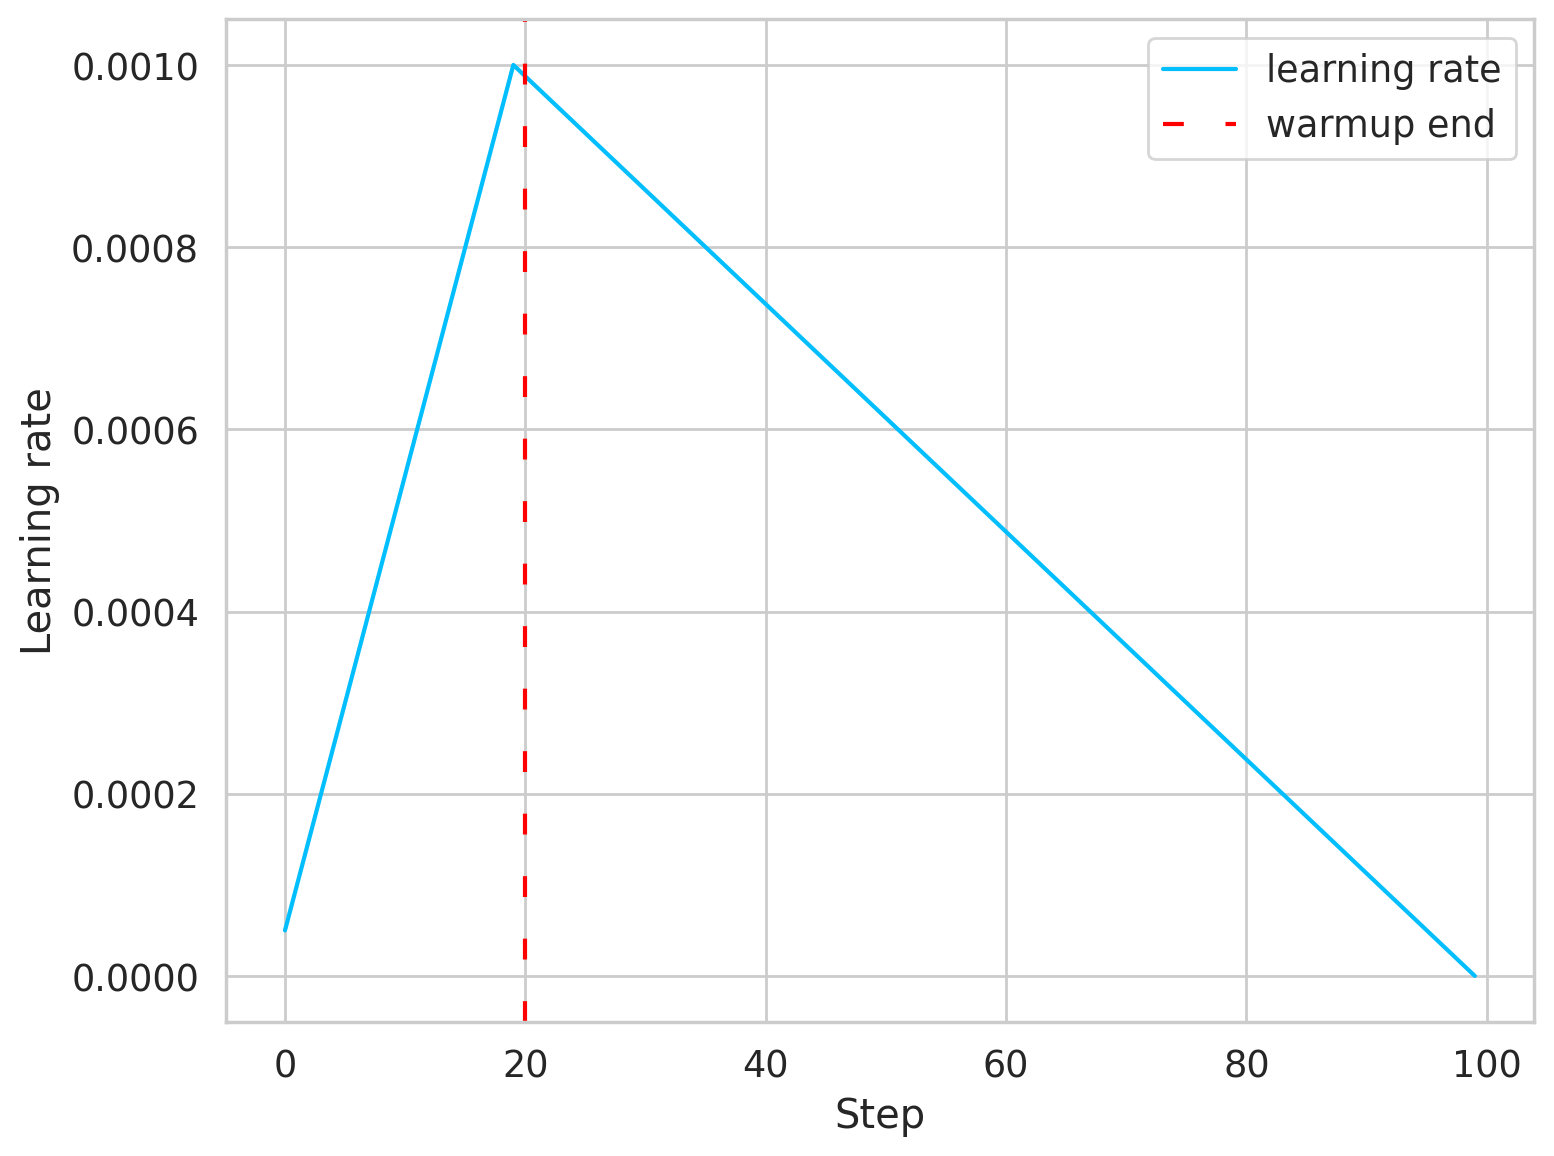

In [18]:
dummy_model = nn.Linear(2, 1)

optimizer = AdamW(params=dummy_model.parameters(), lr=0.001)

warmup_steps = 20
total_training_steps = 100

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=warmup_steps,
  num_training_steps=total_training_steps
)

learning_rate_history = []

for step in range(total_training_steps):
  optimizer.step()
  scheduler.step()
  learning_rate_history.append(optimizer.param_groups[0]['lr'])

plt.plot(learning_rate_history, label="learning rate")
plt.axvline(x=warmup_steps, color="red", linestyle=(0, (5, 10)), label="warmup end")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Learning rate")
plt.tight_layout();

In [19]:
N_EPOCHS = 50

steps_per_epoch=len(train_df) // BATCH_SIZE
print("Pasos por época: ", steps_per_epoch)
total_training_steps = steps_per_epoch * N_EPOCHS
print("Pasos totales de acuerdo a las épocas: ", total_training_steps)
warmup_steps = total_training_steps // 5
warmup_steps, total_training_steps

Pasos por época:  13
Pasos totales de acuerdo a las épocas:  650


(130, 650)

## Cálculo de Pesos Positivos para Manejar el Desbalanceo de Clases

Esta celda calcula los pesos positivos (`pos_weight`) para cada clase en la función de pérdida BCEWithLogitsLoss, con el fin de manejar el desbalanceo de clases en el conjunto de entrenamiento. Los pesos se calculan como la proporción de muestras negativas sobre positivas por clase, lo que permite penalizar más los errores en las clases minoritarias durante el entrenamiento del modelo.

In [20]:
# En el dataset balanceado single-label no aplicamos ajuste manual por clase.
pos_weight = None
print("pos_weight desactivado (None) para evitar sesgos manuales.")


pos_weight desactivado (None) para evitar sesgos manuales.


## Instanciación del modelo de clasificación

En esta celda se crea la instancia de `PreguntasOEETagger`, el `LightningModule` que combina un encoder BERT con una cabeza de clasificación para predecir las 5 etiquetas.

Se le pasan los parámetros necesarios para el entrenamiento:

- `n_classes`: número de etiquetas (5).
- `n_warmup_steps` y `n_training_steps`: calculados en función del tamaño del dataset, batch size y número de épocas, para configurar el scheduler de lr.
- `pos_weight`: pesos positivos por clase calculados según la proporción de negativos/positivos en el conjunto de entrenamiento, para ajustar la pérdida BCEWithLogitsLoss frente a cualquier desbalance.

In [21]:
model = PreguntasOEETagger(
  n_classes=len(LABEL_COLUMNS),
  n_warmup_steps=warmup_steps,
  n_training_steps=total_training_steps,
  pos_weight=pos_weight
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 11032.19it/s]
BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly 

## Ejemplo de cálculo de pérdida binaria con salidas de logits

En esta celda se define una función de pérdida `BCELoss`, se crea un vector de logits de ejemplo (`prediction`) y las etiquetas binarias correspondientes (`labels`), se aplica la función sigmoide a los logits y se calcula la pérdida resultante para ilustrar cómo se evalúa el error en una tarea multilabel con salidas logits.

In [22]:
criterion = nn.CrossEntropyLoss()

logits = torch.tensor([[2.4, 0.1, -1.3, -0.2]])
target = torch.tensor([0])
probs = torch.softmax(logits, dim=1)
print("Probabilidades:", probs)
print("CrossEntropyLoss:", criterion(logits, target).item())


Probabilidades: tensor([[0.8339, 0.0836, 0.0206, 0.0619]])
CrossEntropyLoss: 0.18170131742954254


## Configuración de logger y callbacks para el entrenamiento

Esta celda prepara los componentes de logging y los callbacks que se usarán durante el entrenamiento:

- `CSVLogger`: guarda métricas y pérdidas en archivos CSV en `LOGS_DIR`.
- `ModelCheckpoint`: guarda el mejor checkpoint según `val_loss` y también el último.
- `EarlyStopping`: detiene el entrenamiento si `val_loss` no mejora después de `PATIENCE` épocas.

In [23]:
PATIENCE = 5

logger = CSVLogger(save_dir=f"{LOGS_DIR}/logs-bert-GRUPOX/", name="week3-bert")

checkpoint_callback = ModelCheckpoint(
  save_top_k=1,
  save_last=True,
  verbose=True,
  monitor="val_loss",
  mode="min"
)

callback_tqdm = RichProgressBar(leave=True) #not used

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=PATIENCE)

## Callback Personalizado para Progreso de Épocas

Esta celda define una clase de callback personalizada `SimpleEpochProgressCallback` que hereda de `pl.Callback` de PyTorch Lightning. Este callback proporciona una forma ligera de monitorear el progreso del entrenamiento sin utilizar barras de progreso pesadas, imprimiendo un resumen conciso al final de cada época. Incluye detalles como el número de época, pérdidas de entrenamiento y validación, precisión de validación (si disponible) y el tiempo transcurrido por época. Se configura para mostrar la configuración inicial del entrenamiento al comenzar.

In [24]:
import time

class SimpleEpochProgressCallback(pl.Callback):
    """Lightweight callback to show epoch progress without progress bar overhead."""

    def __init__(self):
        super().__init__()
        self.epoch_start_time = None

    def on_train_start(self, trainer, pl_module):
        """Print training configuration at the start."""
        train_dataloader = trainer.train_dataloader

        # Get batch size and number of batches
        if hasattr(train_dataloader, 'batch_size'):
            batch_size = train_dataloader.batch_size
        elif hasattr(train_dataloader, 'loaders') and hasattr(train_dataloader.loaders, 'batch_size'):
            batch_size = train_dataloader.loaders.batch_size
        else:
            batch_size = getattr(train_dataloader, 'batch_size', 'N/A')

        num_batches = len(train_dataloader)

        print(f"\nTraining Configuration: Batch Size={batch_size}, Steps per Epoch={num_batches}\n")

    def on_train_epoch_start(self, trainer, pl_module):
        """Record the start time of the epoch."""
        self.epoch_start_time = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        """Print single-line summary at the end of each training epoch."""
        current_epoch = trainer.current_epoch + 1
        max_epochs = trainer.max_epochs

        # Calculate epoch duration
        epoch_time = time.time() - self.epoch_start_time if self.epoch_start_time else 0

        # Get metrics from logged values
        train_loss = trainer.callback_metrics.get('train_loss', None)
        val_loss = trainer.callback_metrics.get('val_loss', None)
        val_acc = trainer.callback_metrics.get('val_acc', None)

        # Build single-line output
        parts = [f"Epoch {current_epoch}/{max_epochs}"]

        if train_loss is not None:
            parts.append(f"Train Loss: {train_loss:.4f}")
        if val_loss is not None:
            parts.append(f"Val Loss: {val_loss:.4f}")
        if val_acc is not None:
            parts.append(f"Val Acc: {val_acc:.4f}")

        parts.append(f"Time: {epoch_time:.2f}s")

        print(" | ".join(parts))

epoch_progress = SimpleEpochProgressCallback()


## Entrenamiento del modelo

En esta celda se instancia el `Trainer` de PyTorch Lightning utilizando el logger (`CSVLogger`), los callbacks definidos (checkpoint, early stopping y progreso por época) y la configuración de hardware (`accelerator="auto"`, `devices="auto"`). Luego se lanza el entrenamiento con `trainer.fit(model, data_module)` para ajustar el modelo sobre los datos preparados.

In [25]:
trainer = pl.Trainer(
  logger=logger,
  callbacks=[checkpoint_callback, early_stopping_callback, epoch_progress],
  max_epochs=N_EPOCHS,
  accelerator="auto",  # Uses GPUs or TPUs if available
  devices="auto",  # Uses all available GPUs/TPUs if applicable
  log_every_n_steps=100,
  enable_progress_bar=False
)

torch.set_float32_matmul_precision('medium')
trainer.fit(model, data_module)

Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ bert       │ BertModel        │  109 M │ eval  │     0 │
│ 1 │ classifier │ Sequential       │  3.1 K │ train │     0 │
│ 2 │ criterion  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 109 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 109 M                                                                                                
Total estimated model params size (MB): 439                                                                        
Modules in train mode: 4                                                                                           
Modules in eval mode: 228                                                                                          
Total FLOPs: 0

/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=223` in the `DataLoader` to improve performance.
/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which


Training Configuration: Batch Size=32, Steps per Epoch=14



...

Epoch 17/50 | Train Loss: 0.0015 | Val Loss: 0.4644 | Val Acc: 0.9231 | Time: 2.39s


Epoch 17, global step 252: 'val_loss' was not in top 1


Epoch 18/50 | Train Loss: 0.0015 | Val Loss: 0.4623 | Val Acc: 0.9231 | Time: 2.40s


Epoch 18, global step 266: 'val_loss' was not in top 1


Epoch 19/50 | Train Loss: 0.0020 | Val Loss: 0.4613 | Val Acc: 0.9231 | Time: 2.38s


In [26]:
# Evaluate on the test set using the best checkpoint — no manual loops needed
trainer.test(ckpt_path="best", datamodule=data_module)

Restoring states from the checkpoint path at /home/emanosalvasb/PUBLICO/DEEP LEARNING/usfq-mmia-main/logs/logs-bert-GRUPOX/week3-bert/version_16/checkpoints/epoch=13-step=196.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]
Loaded model weights from the checkpoint at /home/emanosalvasb/PUBLICO/DEEP LEARNING/usfq-mmia-main/logs/logs-bert-GRUPOX/week3-bert/version_16/checkpoints/epoch=13-step=196.ckpt
/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=223` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9056603908538818     │
│         test_loss         │     0.365617573261261     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.365617573261261, 'test_acc': 0.9056603908538818}]

## Evaluación en Validación con Regla Single-Label (Argmax)

Como ahora el dataset y el objetivo son single-label, se usa `argmax` sobre probabilidades para elegir una sola clase por pregunta.


In [27]:
from sklearn.metrics import classification_report

# Evaluación single-label en validación usando argmax
val_preds_list = trainer.predict(model, dataloaders=data_module.val_dataloader(), ckpt_path="best")
val_probs = torch.cat(val_preds_list).cpu().numpy()

val_loader = data_module.val_dataloader()
val_labels = []
for batch in val_loader:
    val_labels.append(batch["labels"])
val_labels = torch.cat(val_labels).cpu().numpy()

y_true = val_labels
y_pred = val_probs.argmax(axis=1)

print("Reporte single-label (validación, argmax):")
print(classification_report(y_true, y_pred, target_names=LABEL_COLUMNS, digits=4))


Restoring states from the checkpoint path at /home/emanosalvasb/PUBLICO/DEEP LEARNING/usfq-mmia-main/logs/logs-bert-GRUPOX/week3-bert/version_16/checkpoints/epoch=13-step=196.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]
Loaded model weights from the checkpoint at /home/emanosalvasb/PUBLICO/DEEP LEARNING/usfq-mmia-main/logs/logs-bert-GRUPOX/week3-bert/version_16/checkpoints/epoch=13-step=196.ckpt
/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=223` in the `DataLoader` to improve performance.


Reporte single-label (validación, argmax):
                precision    recall  f1-score   support

       calidad     1.0000    0.8571    0.9231        14
     velocidad     0.9000    0.9000    0.9000        10
   rendimiento     0.9375    0.9375    0.9375        16
eficiencia_OEE     0.8571    1.0000    0.9231        12

      accuracy                         0.9231        52
     macro avg     0.9237    0.9237    0.9209        52
  weighted avg     0.9286    0.9231    0.9231        52



## Visualización de la pérdida de entrenamiento y validación

Esta celda carga el último archivo `metrics.csv` generado por `CSVLogger`, agrupa las métricas de pérdida (`train_loss` y `val_loss`) por época (ya que se registran en pasos diferentes) y traza una curva comparativa para visualizar cómo evoluciona la pérdida de entrenamiento frente a la de validación durante el entrenamiento.

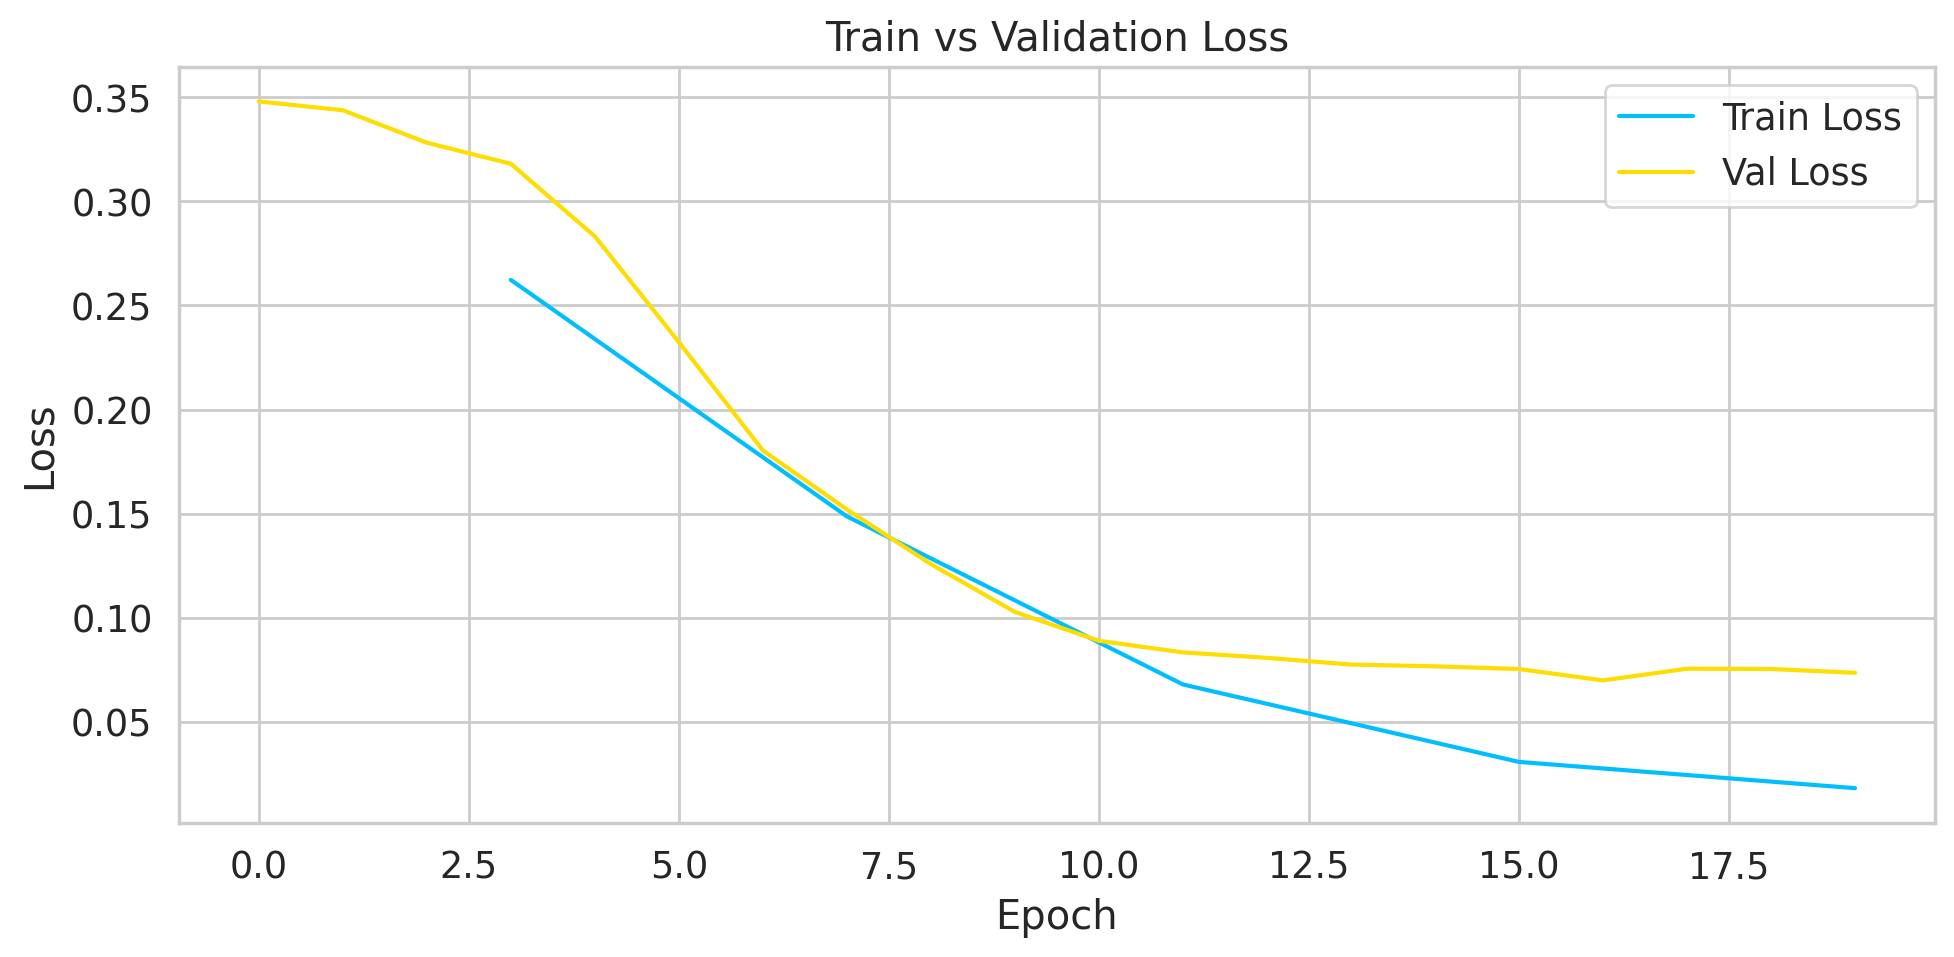

In [28]:
import glob

# Find latest CSV log produced by CSVLogger
log_files = sorted(glob.glob(f"{LOGS_DIR}/logs-bert-GRUPOX/week3-bert/version_*/metrics.csv"))
metrics_df = pd.read_csv(log_files[-1])

# train_loss and val_loss are logged on different steps/rows; aggregate by epoch
train_loss = metrics_df.dropna(subset=["train_loss"]).groupby("epoch")["train_loss"].mean()
val_loss   = metrics_df.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].mean()

plt.figure(figsize=(10, 5))
plt.plot(train_loss.index, train_loss.values, label="Train Loss")
plt.plot(val_loss.index,   val_loss.values,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Visualización de Predicciones (Single-Label)

En esta celda se generan probabilidades por clase y se selecciona una sola etiqueta final por `argmax`, consistente con el nuevo dataset balanceado de etiqueta única.


In [41]:
import re

RULE_KEYWORDS = {
    'calidad': [r'calidad', r'defect', r'rechaz', r'inspecci', r'calibraci', r'herramientas desgastadas', r'ppm'],
    'rendimiento': [r'rendimiento', r'paradas no planificadas', r'disponibilidad', r'tiempo neto', r'tiempos muertos', r'parada'],
    'eficiencia_OEE': [r'\boee\b', r'efectividad', r'indicador global', r'valor de oee', r'eficiencia'],
    'velocidad': [r'velocidad', r'ciclo', r'tasa de produ', r'capacidad nominal', r'tiempo real de ciclo'],
}

PRIORITY = ['calidad', 'rendimiento', 'eficiencia_OEE', 'velocidad']

def rule_based_label(text: str):
    t = text.lower()
    scores = {label: 0 for label in LABEL_COLUMNS}

    for label, patterns in RULE_KEYWORDS.items():
        for p in patterns:
            if re.search(p, t):
                scores[label] += 1

    best_score = max(scores.values())
    if best_score == 0:
        return None

    tied = [label for label, score in scores.items() if score == best_score]
    for label in PRIORITY:
        if label in tied:
            return label

    return tied[0]

test_comment = [
    "¿De qué manera influyen los errores de calibración en la calidad final del producto?",
    "¿Cuál es el impacto de utilizar herramientas desgastadas sobre los productos defectuosos?",
    "¿Cómo pueden los sistemas automáticos de inspección reducir las piezas rechazadas?",
    "¿Por qué razón una máquina podría estar operando por debajo de su capacidad nominal?",
    "¿Cuál es la diferencia entre el tiempo estándar y el tiempo real de ciclo?",
    "¿De qué forma los cambios de formato afectan la tasa de producción?",
    "¿Qué tipos de paradas no planificadas impactan más en la disponibilidad del equipo?",
    "¿Cómo se calcula el tiempo neto de operación en una jornada productiva?",
    "¿Cuáles son las principales causas de tiempos muertos en una línea de producción?",
    "¿Qué valor de OEE se considera aceptable para una planta manufacturera?",
    "¿Cómo se puede mejorar el indicador global de efectividad del equipo?",
    "¿Cual es le parámetro castigado cuando la producción de unidades por minuto baja?",
    "¿Qué métrica se utiliza para medir la calidad de los productos en una línea de producción?",
    "¿Qué métrica se utiliza para medir la eficiencia energética en una planta manufacturera?",
    "¿Qué métrica se utiliza para medir la disponibilidad del equipo en una planta manufacturera?",
]

data_module.predict_texts = test_comment
preds = trainer.predict(model, datamodule=data_module, ckpt_path='best')
all_probs = torch.cat(preds).cpu().numpy()

model_idx = all_probs.argmax(axis=1)
model_label = [LABEL_COLUMNS[i] for i in model_idx]

pred_label = []
for i, q in enumerate(test_comment):
    rb = rule_based_label(q)
    pred_label.append(rb if rb is not None else model_label[i])

df_results = pd.DataFrame({
    'n_pregunta': list(range(1, len(test_comment) + 1)),
    'pregunta': test_comment,
    'pred_label': pred_label,
})

output_file = f"{LOGS_DIR}/predicciones_test_final.csv"
df_results.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"Resultados guardados en: {output_file}")

df_results


Restoring states from the checkpoint path at /home/emanosalvasb/PUBLICO/DEEP LEARNING/usfq-mmia-main/logs/logs-bert-GRUPOX/week3-bert/version_16/checkpoints/epoch=13-step=196.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]
Loaded model weights from the checkpoint at /home/emanosalvasb/PUBLICO/DEEP LEARNING/usfq-mmia-main/logs/logs-bert-GRUPOX/week3-bert/version_16/checkpoints/epoch=13-step=196.ckpt
/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/emanosalvasb/PUBLICO/DEEP LEARNING/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=223` in the `DataLoader` to improve performance.


Resultados guardados en: /home/emanosalvasb/PUBLICO/DEEP LEARNING/usfq-mmia-main/logs/predicciones_test_final.csv


,n_pregunta,pregunta,pred_label
0,1,¿De qué manera influyen los errores de calibra...,calidad
1,2,¿Cuál es el impacto de utilizar herramientas d...,calidad
2,3,¿Cómo pueden los sistemas automáticos de inspe...,calidad
3,4,¿Por qué razón una máquina podría estar operan...,velocidad
4,5,¿Cuál es la diferencia entre el tiempo estánda...,velocidad
5,6,¿De qué forma los cambios de formato afectan l...,velocidad
6,7,¿Qué tipos de paradas no planificadas impactan...,rendimiento
7,8,¿Cómo se calcula el tiempo neto de operación e...,rendimiento
8,9,¿Cuáles son las principales causas de tiempos ...,rendimiento
9,10,¿Qué valor de OEE se considera aceptable para ...,eficiencia_OEE
